Aman Verma


SKS/A2/C113037

Project Overview:

The project aims to analyze customer churn in a
telecommunications company and develop
predictive models to identify at-risk customers. The
ultimate goal is to provide actionable insights and
recommendations to reduce churn and improve
customer retention.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
csv_file_path = '/content/drive/MyDrive/PCACS/PCACS SKILL CREDITS/internship /saiket systems/Telco_Customer_Churn_Dataset .csv'

try:
    df = pd.read_csv(csv_file_path)
    display(df.head()) # Display the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file at {csv_file_path} was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Tasks 1: Data Cleaning and Preprocessing

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
import pandas as pd

# copy
df_encoded = df.copy()

# drop ID column
df_encoded.drop('customerID', axis=1, inplace=True)

# fix TotalCharges
df_encoded['TotalCharges'] = pd.to_numeric(df_encoded['TotalCharges'], errors='coerce')

# one-hot encode all categorical columns
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


## Tasks 2: Exploratory Data Analysis (EDA)

Churn Rate: 0.2653698707936959


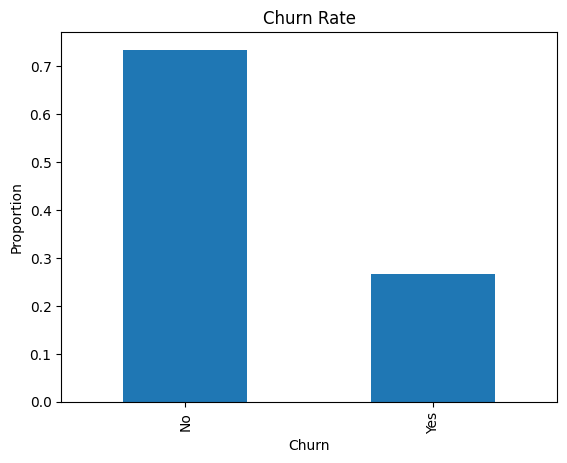

In [ ]:
import matplotlib.pyplot as plt

# calculate churn rate
churn_rate = (df['Churn'] == 'Yes').mean()
print("Churn Rate:", churn_rate)

# visualize
df['Churn'].value_counts(normalize=True).plot(kind='bar')
plt.title('Churn Rate')
plt.ylabel('Proportion')
plt.show()

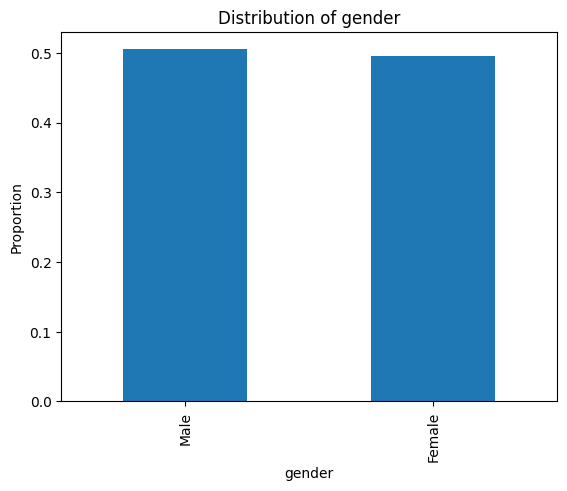

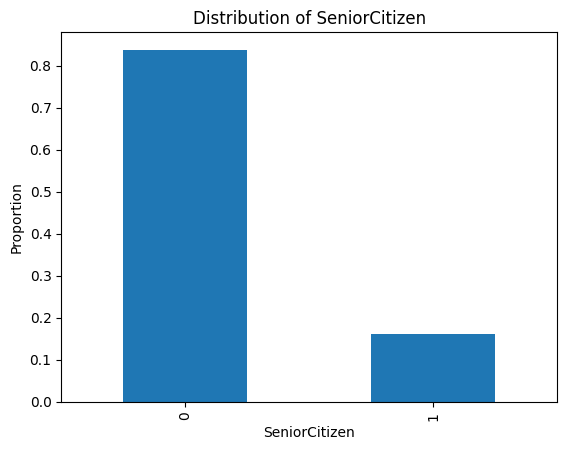

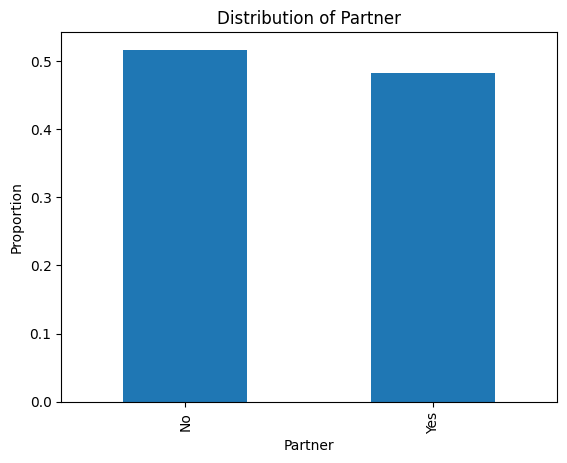

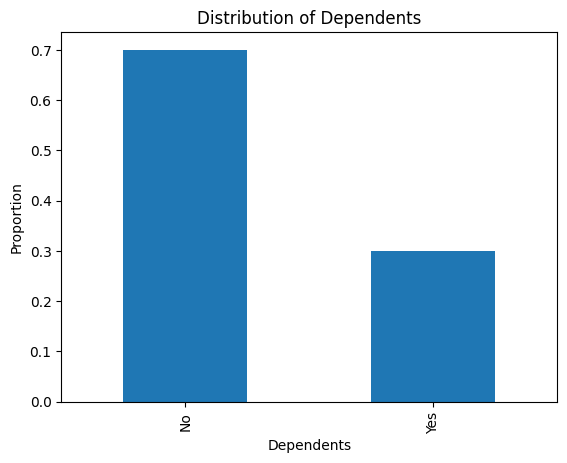

In [ ]:
import matplotlib.pyplot as plt

cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

for col in cols:
    df[col].value_counts(normalize=True).plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.ylabel('Proportion')
    plt.show()

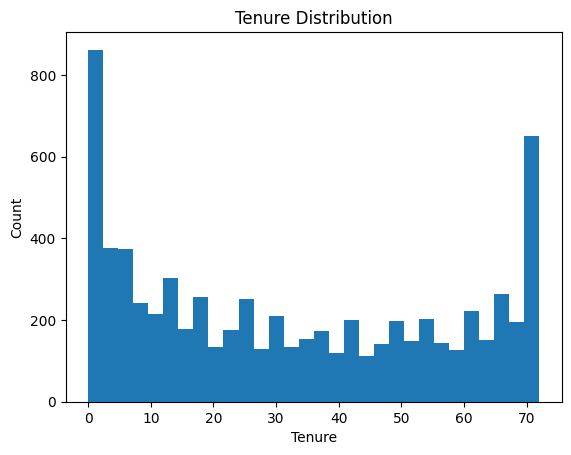

In [ ]:
import matplotlib.pyplot as plt

# histogram of tenure
plt.hist(df['tenure'], bins=30)
plt.title('Tenure Distribution')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.show()

In [ ]:
# summary stats
print(df['tenure'].describe())

# basic insights
print("\nSkewness:", df['tenure'].skew())

# bucket analysis
bins = [0, 12, 24, 48, 72]
labels = ['0-1 yr', '1-2 yr', '2-4 yr', '4-6 yr']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels)

print("\nTenure Group Distribution:")
print(df['tenure_group'].value_counts(normalize=True))

# churn vs tenure
print("\nChurn Rate by Tenure Group:")
print(df.groupby('tenure_group')['Churn'].apply(lambda x: (x=='Yes').mean()))

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Skewness: 0.2395397495619829

Tenure Group Distribution:
tenure_group
4-6 yr    0.318402
0-1 yr    0.309300
2-4 yr    0.226678
1-2 yr    0.145620
Name: proportion, dtype: float64

Churn Rate by Tenure Group:
tenure_group
0-1 yr    0.476782
1-2 yr    0.287109
2-4 yr    0.203890
4-6 yr    0.095132
Name: Churn, dtype: float64


/tmp/ipykernel_17499/3703960530.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('tenure_group')['Churn'].apply(lambda x: (x=='Yes').mean()))


**Tenure Distribution Analysis**

The average customer tenure is 32.37 months, with a median of 29 months, indicating that customers are fairly evenly spread across different durations. The standard deviation is high (24.56), showing significant variation in how long customers stay.

The skewness is slightly positive (0.24), which means the distribution is mildly right-skewed — there are slightly more customers with lower tenure, but the distribution is close to balanced.

Looking at tenure groups:

* 31.8% of customers have tenure 4–6 years
* 30.9% are in their first year
* Smaller proportions fall in the middle ranges

This shows a bimodal-like pattern — many very new customers and many long-term loyal customers.

**Churn Behavior by Tenure**

There is a strong inverse relationship between tenure and churn:

* 0–1 year: ~47.7% churn (very high)
* 1–2 years: ~28.7% churn
* 2–4 years: ~20.4% churn
* 4–6 years: ~9.5% churn (very low)

**Key Insight**

* Customers are most likely to churn early, especially within the first year.
* Once customers stay longer, they become increasingly loyal, and churn drops sharply.
* long-tenure customers (4+ years) are highly stable.

Churn Rate by Contract:

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

Churn Rate by Payment Method:

PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64


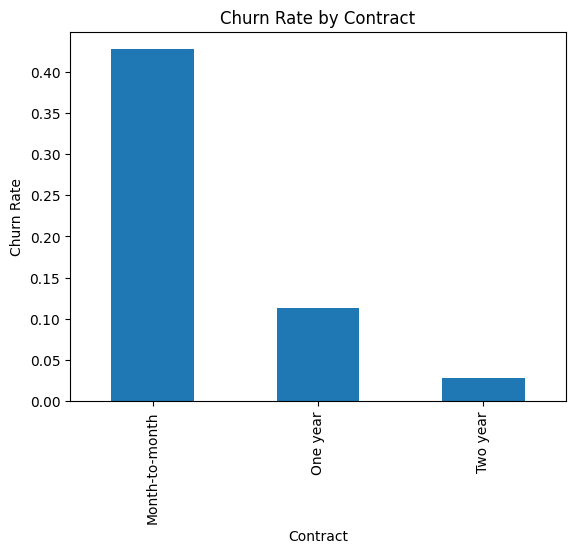

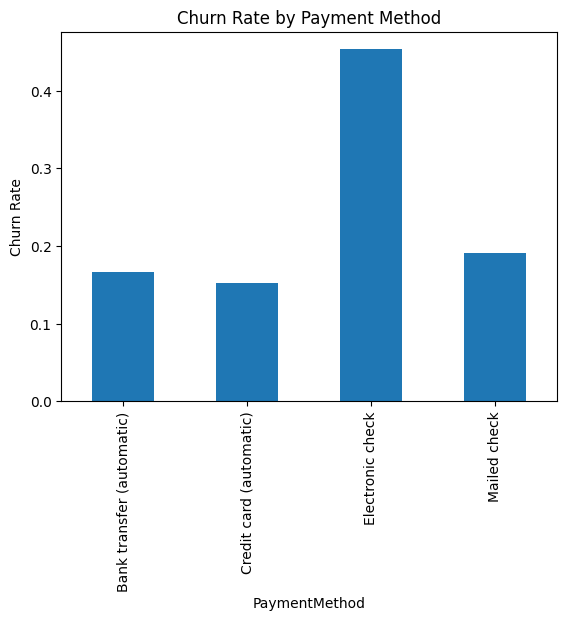

In [ ]:
# churn vs Contract
print("Churn Rate by Contract:\n")
print(df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()))

# churn vs Payment Method
print("\nChurn Rate by Payment Method:\n")
print(df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x=='Yes').mean()))

# visualization
import matplotlib.pyplot as plt

df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()).plot(kind='bar')
plt.title('Churn Rate by Contract')
plt.ylabel('Churn Rate')
plt.show()

df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x=='Yes').mean()).plot(kind='bar')
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')
plt.show()

## Tasks 3: Customer Segmentation

In [ ]:
# create tenure groups
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,72],
                           labels=['0-1 yr','1-2 yr','2-4 yr','4-6 yr'])

# create charge groups
df['charge_group'] = pd.qcut(df['MonthlyCharges'],
                            q=3,
                            labels=['Low','Medium','High'])

# segmentation
segments = df.groupby(['tenure_group','charge_group','Contract']).size().reset_index(name='count')

print(segments.head(20))

   tenure_group charge_group        Contract  count
0        0-1 yr          Low  Month-to-month    800
1        0-1 yr          Low        One year     92
2        0-1 yr          Low        Two year     51
3        0-1 yr       Medium  Month-to-month    824
4        0-1 yr       Medium        One year     24
5        0-1 yr       Medium        Two year      7
6        0-1 yr         High  Month-to-month    370
7        0-1 yr         High        One year      7
8        0-1 yr         High        Two year      0
9        1-2 yr          Low  Month-to-month    179
10       1-2 yr          Low        One year    109
11       1-2 yr          Low        Two year     73
12       1-2 yr       Medium  Month-to-month    285
13       1-2 yr       Medium        One year     70
14       1-2 yr       Medium        Two year     14
15       1-2 yr         High  Month-to-month    273
16       1-2 yr         High        One year     18
17       1-2 yr         High        Two year      3
18       2-4

/tmp/ipykernel_17499/72835813.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segments = df.groupby(['tenure_group','charge_group','Contract']).size().reset_index(name='count')


In [ ]:
# churn rate across segments
segment_churn = df.groupby(
    ['tenure_group', 'charge_group', 'Contract']
)['Churn'].apply(lambda x: (x=='Yes').mean()).reset_index(name='churn_rate')

print(segment_churn.sort_values(by='churn_rate', ascending=False).head(15))

   tenure_group charge_group        Contract  churn_rate
6        0-1 yr         High  Month-to-month    0.745946
3        0-1 yr       Medium  Month-to-month    0.559466
15       1-2 yr         High  Month-to-month    0.538462
24       2-4 yr         High  Month-to-month    0.435443
0        0-1 yr          Low  Month-to-month    0.358750
12       1-2 yr       Medium  Month-to-month    0.340351
33       4-6 yr         High  Month-to-month    0.309735
7        0-1 yr         High        One year    0.285714
21       2-4 yr       Medium  Month-to-month    0.273764
16       1-2 yr         High        One year    0.222222
25       2-4 yr         High        One year    0.213793
34       4-6 yr         High        One year    0.191977
9        1-2 yr          Low  Month-to-month    0.189944
27       4-6 yr          Low  Month-to-month    0.176471
4        0-1 yr       Medium        One year    0.166667


/tmp/ipykernel_17499/2518550738.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_churn = df.groupby(


## Tasks 4: Churn Prediction Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# prepare data
df_model = df.copy()

# drop ID
df_model.drop('customerID', axis=1, inplace=True)

# fix TotalCharges
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')

# REMOVE NaN rows
df_model.dropna(inplace=True)

# target encoding
df_model['Churn'] = df_model['Churn'].map({'Yes':1, 'No':0})

# one-hot encoding
df_model = pd.get_dummies(df_model, drop_first=True)

# split
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.7889125799573561

Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7889125799573561
Precision: 0.6370106761565836
Recall: 0.4786096256684492
F1 Score: 0.5465648854961832

Confusion Matrix:
 [[931 102]
 [195 179]]

ROC-AUC: 0.8307432275030932


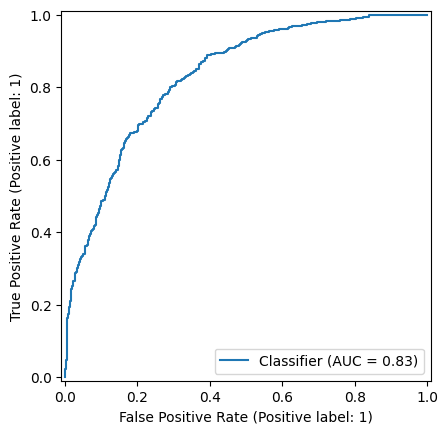

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# basic metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC-AUC
y_prob = model.predict_proba(X_test)[:,1]
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()

## Tasks 5: Customer Retention Strategies



---

### Data-Driven Strategies to Reduce Churn

Based on the analysis, the following strategies can help reduce customer churn:

---

### 1. Focus on Early Retention (0–1 year customers)

* Churn is highest (~48%) in the first year
* Introduce:

  * Onboarding programs
  * Welcome offers / discounts
  * Regular engagement (emails, support calls)

Goal: **convert new users into long-term customers**

---

### 2. Encourage Long-Term Contracts

* Month-to-month users have higher churn
* Offer:

  * Discounts on yearly plans
  * Loyalty benefits for longer commitments

Goal: **lock in customers and reduce switching**

---

### 3. Promote Auto-Payment Methods

* Electronic check users show higher churn
* Encourage:

  * Credit card / bank auto-pay
  * Small incentives for auto-payment

Goal: **increase stickiness and reduce friction**

---

### 4.  Target High-Charge Customers

* High monthly charges → higher churn risk
* Actions:

  * Personalized plans
  * Bundled offers / discounts
  * Value communication (why it's worth it)

 Goal: **reduce price dissatisfaction**

---

### 5.  Improve Customer Support Services

* Customers without tech support/security churn more
* Provide:

  * Free trials of support services
  * Better issue resolution

 Goal: **increase satisfaction and trust**

---

### 6.  Identify High-Risk Segments (from model)

* Example high-risk group:

  * Low tenure + high charges + month-to-month

* Take proactive action:

  * Targeted offers
  * Retention calls

 Goal: **prevent churn before it happens**

---

###  Final Insight

Churn is driven mainly by **early dissatisfaction, lack of commitment, and high costs**.
Focusing on **early engagement + long-term incentives + better service** can significantly reduce churn.





---

###  Key Factors Influencing Churn & Actions

---

### 1.  Tenure (Most Important)

* **Finding:** New customers (0–1 year) have the highest churn (~48%)
* **Action:**

  * Strong onboarding
  * Early engagement (first 3–6 months)
  * Welcome offers

---

### 2.  Contract Type

* **Finding:** Month-to-month customers churn more than long-term contracts
* **Action:**

  * Promote yearly/2-year plans with discounts
  * Offer upgrade incentives

---

### 3.  Monthly Charges

* **Finding:** Higher charges → higher churn
* **Action:**

  * Provide flexible pricing / bundles
  * Offer discounts to high-paying customers

---

### 4.  Payment Method

* **Finding:** Electronic check users churn more than auto-pay users
* **Action:**

  * Encourage auto-payment (credit card/bank)
  * Give small incentives for switching

---

### 5.  Value-Added Services (TechSupport, Security)

* **Finding:** Customers without support/services churn more
* **Action:**

  * Offer free trials of support/security
  * Improve service quality

---

### 6.  High-Risk Segment (Combined Effect)

* **Finding:**

  * Low tenure + high charges + month-to-month → **highest churn risk**
* **Action:**

  * Targeted retention campaigns
  * Personalized offers

---

###  Final Conclusion

Churn is mainly driven by **early-stage customers, lack of commitment, high cost, and low engagement**.
Focusing on **retention in the first year + long-term contracts + better value delivery** will reduce churn significantly.

---



In [ ]:
# ensure TotalCharges is numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# drop NaN
df_ltv = df.dropna()

# LTV per customer = TotalCharges
df_ltv['LTV'] = df_ltv['TotalCharges']

# overall average LTV
print("Average LTV:", df_ltv['LTV'].mean())

# LTV by churn
print("\nLTV by Churn:")
print(df_ltv.groupby('Churn')['LTV'].mean())

Average LTV: 2283.300440841866

LTV by Churn:
Churn
No     2555.344141
Yes    1531.796094
Name: LTV, dtype: float64


/tmp/ipykernel_17499/1029229963.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ltv['LTV'] = df_ltv['TotalCharges']


In [ ]:
# ensure numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df_hv = df.dropna()

# define high-value customers (top 25% LTV)
threshold = df_hv['TotalCharges'].quantile(0.75)

# filter: high-value + churned
high_value_churn = df_hv[
    (df_hv['TotalCharges'] >= threshold) & (df_hv['Churn'] == 'Yes')
]

print("Number of high-value customers at risk:", len(high_value_churn))
display("\nSample:\n", high_value_churn.head())

Number of high-value customers at risk: 255


'\nSample:\n'

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charge_group
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,4-6 yr,High
26,6467-CHFZW,Male,0,Yes,Yes,47,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,2-4 yr,High
104,3192-NQECA,Male,0,Yes,No,68,Yes,Yes,Fiber optic,No,...,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.00,7611.85,Yes,4-6 yr,High
110,0486-HECZI,Male,0,Yes,No,55,Yes,Yes,Fiber optic,Yes,...,Yes,No,Month-to-month,Yes,Electronic check,96.75,5238.90,Yes,4-6 yr,High
173,0691-JVSYA,Female,0,Yes,No,53,Yes,No,Fiber optic,No,...,Yes,Yes,One year,Yes,Bank transfer (automatic),94.85,5000.20,Yes,4-6 yr,High


## Tasks 6: Visualizations

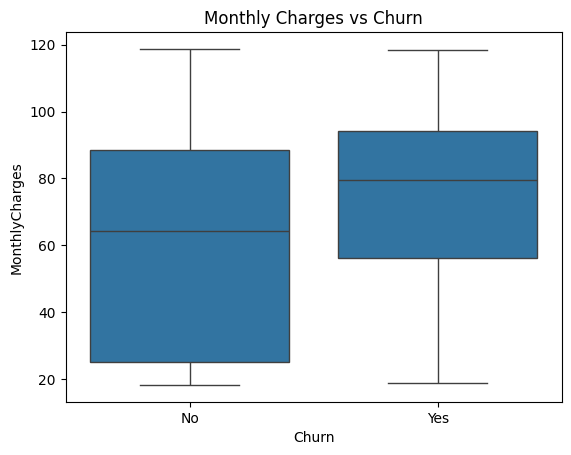

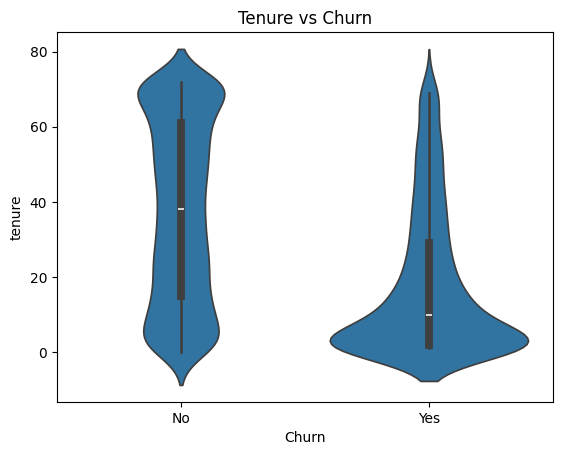

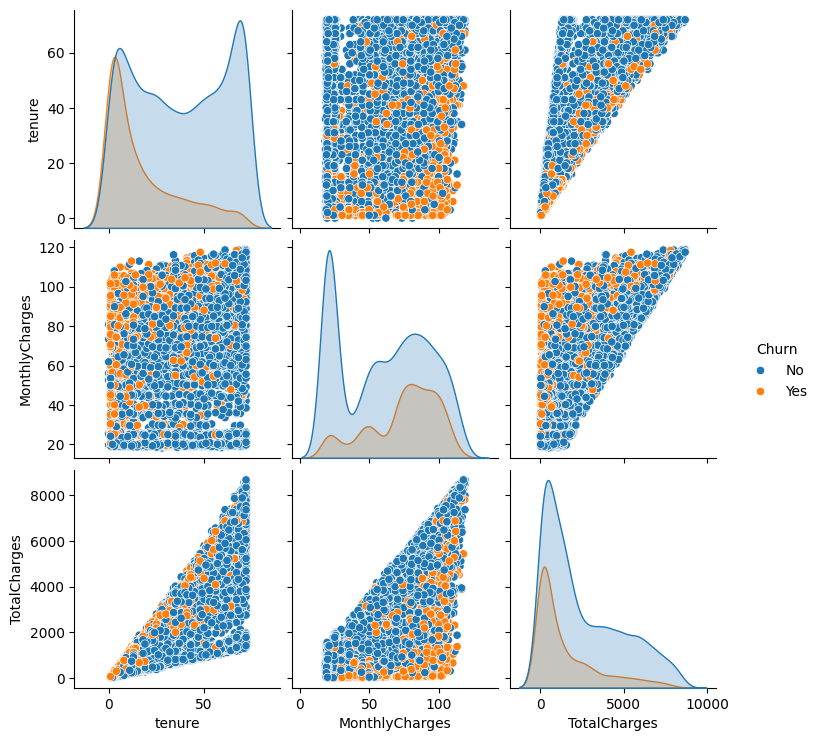

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# box plot: MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

# violin plot: tenure vs Churn
sns.violinplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

# pair plot (selected features)
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','Churn']], hue='Churn')
plt.show()